In [ ]:
import numpy as np
import cv2
import os
import zipfile
import requests
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
url = "https://github.com/robaita/introduction_to_machine_learning/raw/main/dataset.zip"
r = requests.get(url)
open("dataset.zip", "wb").write(r.content)

with zipfile.ZipFile("dataset.zip", "r") as z:
    z.extractall("faces_dataset")

IMG_SIZE = (100, 100)
Face_Db = []
labels = []
label_map = {}
person_id = 0

for root, dirs, files in os.walk("faces_dataset"):
    for file in files:
        if file.endswith(".pgm") or file.endswith(".jpg") or file.endswith(".png"):
            path = os.path.join(root, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)
            Face_Db.append(img.flatten())
            person_name = os.path.basename(root)
            if person_name not in label_map:
                label_map[person_name] = person_id
                person_id += 1
            labels.append(label_map[person_name])

Face_Db = np.array(Face_Db).T  # shape: (mn, p)
labels = np.array(labels)

mn, p = Face_Db.shape
print(f"Face Database shape: {Face_Db.shape}")

Face Database shape: (10000, 443)


In [ ]:
M = np.mean(Face_Db, axis=1).reshape(-1, 1)
Delta = Face_Db - M

In [ ]:
C = np.dot(Delta.T, Delta)

In [ ]:
eigvals, eigvecs = np.linalg.eigh(C)

# Sort in descending order
idx = np.argsort(-eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

In [ ]:
def run_pca_ann(k):
    Psi = eigvecs[:, :k]  # shape: p x k
    Phi = np.dot(Delta, Psi)  # shape: mn x k

    # Normalize eigenfaces
    for i in range(Phi.shape[1]):
        Phi[:, i] /= np.linalg.norm(Phi[:, i])

    omega = np.dot(Phi.T, Delta)  # shape: k x p

    X_train, X_test, y_train, y_test = train_test_split(omega.T, labels, test_size=0.4, random_state=42)
    y_train_cat = to_categorical(y_train)
    y_test_cat = to_categorical(y_test)

    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(k,)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(len(np.unique(labels)), activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train_cat, epochs=50, batch_size=8, verbose=0)
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)

    return acc

In [ ]:
k = 20  # For example, choose 20 eigenfaces

Psi = eigvecs[:, :k]          # shape: p x k
Phi = np.dot(Delta, Psi)      # shape: mn x k

# Phi: eigenfaces in image space
Psi = eigvecs[:, :k]          # shape: p x k (from Step 5)
Phi = np.dot(Delta, Psi)      # shape: mn x k

# Normalize each eigenface (column)
for i in range(Phi.shape[1]):
    Phi[:, i] /= np.linalg.norm(Phi[:, i])

omega = np.dot(Phi.T, Delta)  # shape: k x p

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(omega.T, labels, test_size=0.4, random_state=42)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(k,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(labels)), activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train_cat, epochs=50, batch_size=8, verbose=0)
loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


k=5, Accuracy=0.4270
k=10, Accuracy=0.4213
k=20, Accuracy=0.3876
k=30, Accuracy=0.4888
k=40, Accuracy=0.5000
k=75, Accuracy=0.4270
k=90, Accuracy=0.5056
k=100, Accuracy=0.4888
k=120, Accuracy=0.4663


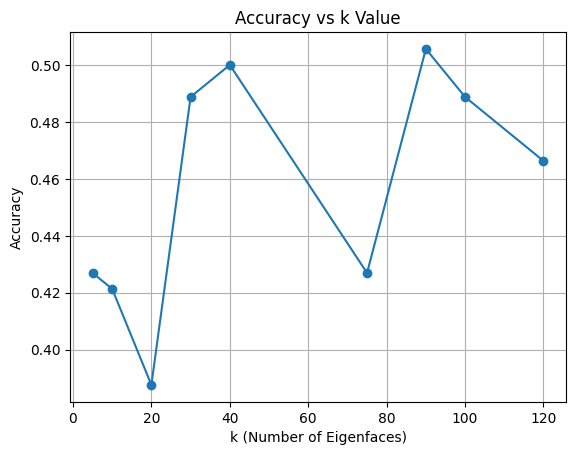

In [ ]:
k_values = [5, 10, 20, 30, 40, 75, 90, 100, 120]
accuracies = []

for k in k_values:
    acc = run_pca_ann(k)
    accuracies.append(acc)
    print(f"k={k}, Accuracy={acc:.4f}")

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k (Number of Eigenfaces)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k Value")
plt.grid(True)
plt.show()

In [ ]:
def recognize_faces_in_image(image_path, model, Phi, M, label_map_inv, threshold=0.7):
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found or cannot be loaded.")
        return

    face_imgs, boxes = detect_faces(img)

    if len(face_imgs) == 0:
        print("No face detected in the image.")
        return

    print(f"{len(face_imgs)} face(s) detected.")
    for i, face_img in enumerate(face_imgs):
        result = predict_face(model, Phi, M, face_img, label_map_inv, threshold=threshold)
        print(f"Face {i+1}: Recognized as '{result}'")

        # Draw bounding box and label
        (x, y, w, h) = boxes[i]
        label_text = result
        color = (0, 255, 0) if result != "Unknown" else (0, 0, 255)
        cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
        cv2.putText(img, label_text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Show annotated image inline (Colab)
    from google.colab.patches import cv2_imshow
    cv2_imshow(img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

def train_evaluate_ann(X, y, epochs=50):
    """
    Train and evaluate an ANN classifier.

    Parameters:
    - X: numpy array shape (num_samples, num_features), input features (signature vectors)
    - y: numpy array shape (num_samples,), integer labels (class IDs)
    - epochs: int, number of training epochs (default 50)

    Returns:
    - model: trained Keras model
    - test_accuracy: accuracy evaluated on test set
    """
    # One-hot encode labels
    y_cat = to_categorical(y)

    # Split data into train(60%) and test(40%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_cat, test_size=0.4, random_state=42, stratify=y)

    # Define the model architecture
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(X.shape[1],)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(y_cat.shape[1], activation='softmax'))  # number of classes = y_cat.shape[1]

    # Compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Use early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train model
    model.fit(X_train, y_train, epochs=epochs, batch_size=8,
              validation_split=0.2, verbose=0, callbacks=[early_stop])

    # Evaluate on test set
    loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test accuracy: {test_accuracy:.4f}")

    return model, test_accuracy


In [ ]:
# Mean face
M = np.mean(Face_Db, axis=1).reshape(-1, 1)

# Mean-centered data
Delta = Face_Db - M

# Surrogate covariance
L = Delta.T @ Delta

# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(L)

# Sort eigenvalues and eigenvectors
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Eigenfaces in original space
U = Delta @ eigenvectors
U = U / np.linalg.norm(U, axis=0)   # Normalize columns


In [ ]:
def generate_signatures(k):
    """
    Generate eigenfaces (Phi) and signatures (Omega) for top-k components.
    """
    U_k = U[:, :k]                 # Eigenfaces (mn x k)
    Omega = U_k.T @ Delta          # Projected signatures (k x p)
    return U_k, Omega


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def train_evaluate_ann(Omega, labels, epochs=200):
    """
    Train and evaluate ANN on given signatures.
    Returns trained model and accuracy.
    """
    X = Omega.T   # (p, k)
    le = LabelEncoder()
    y = le.fit_transform(labels)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

    model = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                          max_iter=epochs, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy with k={X.shape[1]}: {acc:.4f}")
    return model, acc


In [ ]:
k_final = 30
Phi_final, omega_final = generate_signatures(k_final)
final_model, _ = train_evaluate_ann(omega_final, labels, epochs=50)


Accuracy with k=30: 0.3652


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Example code to load and preprocess imposter images from a folder

imposter_images_folder = "/content/drive/MyDrive/imposter images" # **Replace with the actual path to your imposter image folder**
imposter_images = []
IMG_SIZE = (100, 100) # Ensure this matches the size used for the training data

if os.path.exists(imposter_images_folder):
    for filename in os.listdir(imposter_images_folder):
        # Check for common image file extensions, including case-insensitivity
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.pgm', '.bmp')):
            img_path = os.path.join(imposter_images_folder, filename)
            # Read image in color
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is not None:
                # Resize color image
                img = cv2.resize(img, IMG_SIZE)
                # Flatten color image (will have 3 times the size of grayscale)
                imposter_images.append(img.flatten())
            else:
                print(f"Could not read image: {img_path}")
else:
    print(f"Imposter images folder not found at: {imposter_images_folder}")

# Now imposter_images list is populated with flattened imposter images.
# You can now proceed with the rest of the code in the next cell (preparing imposter signatures and evaluation).

Imposter Image 1:


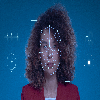

Imposter Image 2:


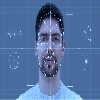

Imposter Image 3:


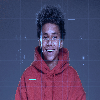

Imposter Image 4:


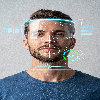

In [ ]:
# Reshape and display the imposter images
for i, imposter_img_flat in enumerate(imposter_images):
    # Reshape flattened color image (size IMG_SIZE[0] * IMG_SIZE[1] * 3)
    imposter_img = imposter_img_flat.reshape((IMG_SIZE[0], IMG_SIZE[1], 3))
    print(f"Imposter Image {i+1}:")
    from google.colab.patches import cv2_imshow
    cv2_imshow(imposter_img)